352
nombre d'options: 352


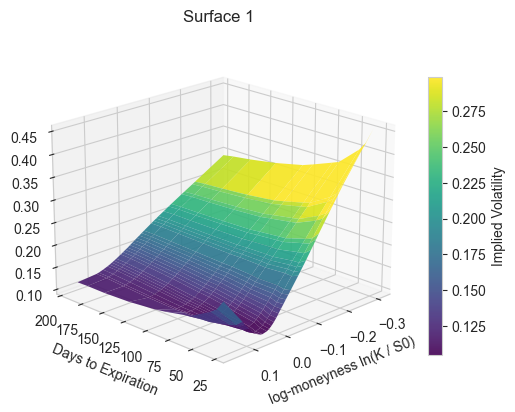

In [1]:
from utils.options_utils import get_options_data
from vol_surface import Vol_Surface, max_area_complete_grid
from heston_pricing import HestonParams, Config, HestonCalibration
from utils.options_utils import tenor_to_days
from option_pricing import compute_iv, filter_df
import pandas as pd
import numpy as np

ticker = "SPY"
date = "2025-12-19"
config = Config(ticker, date)

raw_df = get_options_data(config)
df = filter_df(raw_df)

K_grid, tau_grid = max_area_complete_grid(df)
df = df[df["strike"].isin(K_grid) & df["tau"].isin(tau_grid)]
vol_surface = Vol_Surface(config)

vol_surface.volatility_surface([df])
# vol_surface.skew(df, daysToExpiration=100, visual="log-moneyness")
# vol_surface.greeks(df, greek="delta", daysToExpiration= 10)

In [ ]:
heston_calibration = HestonCalibration(df=df, raw_df=raw_df, config=config)
theta0 = HestonParams(kappa=3.0, v_bar=0.1, sigma=0.25, rho=-0.8, v0=0.08)

thetaf = heston_calibration.LM_algorithm(theta0=theta0, max_iter=30)